⚙️ Paso 1: Procesando datos y creando Motor de Inteligencia...
🌲 Paso 2: Entrenando el algoritmo Random Forest...
🔮 Paso 3: Proyectando el año 2026 para Hurto en Eixample...

✅ CALENDARIO DE RIESGO 2026 GENERADO:


,Mes,Predicción_2026
0,Enero,1873
1,Febrero,1910
2,Marzo,2027
3,Abril,2056
4,Mayo,2101
5,Junio,2122
6,Julio,2172
7,Agosto,2218
8,Septiembre,2177
9,Octubre,2194


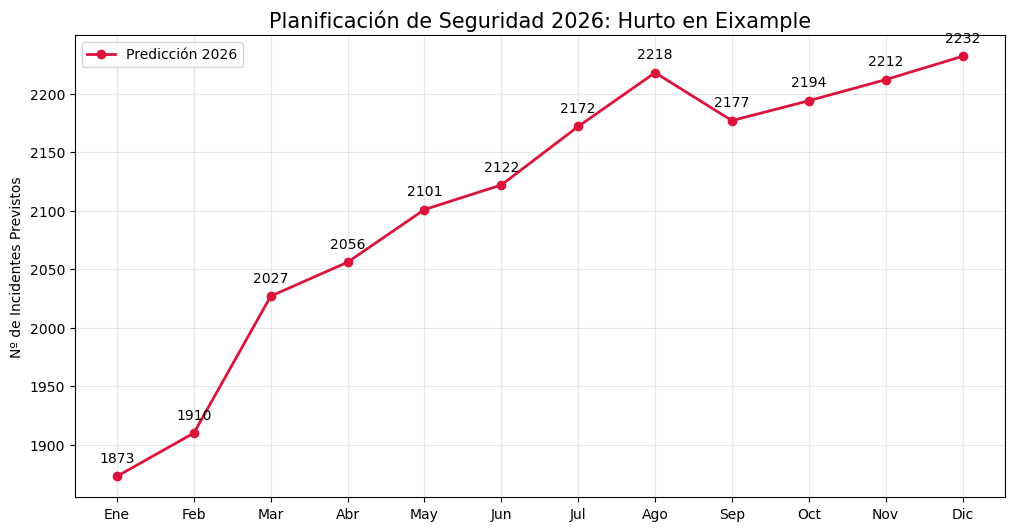

📁 Informe guardado exitosamente como: Plan_Seguridad_2026_Eixample_Hurto.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display

print("⚙️ Paso 1: Procesando datos y creando Motor de Inteligencia...")

# 1. Función de limpieza
def limpiar_socio(path, pivot_col):
    df = pd.read_csv(path)
    if 'Poblacion' in path:
        df.columns = [str(col).split()[-1] if '01 ene' in str(col).lower() else col for col in df.columns]
        df = df[df['Tipo de territorio'].isin(['Municipi', 'Districte'])]
    
    columnas_años = [c for c in df.columns if c not in ['Territorio', 'Tipo de territorio', pivot_col]]
    for col in columnas_años:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False)\
                                     .str.replace('-', '0', regex=False)\
                                     .str.replace(' ', '', regex=False)\
                                     .replace('', '0')\
                                     .astype(float)
    
    melted = df.melt(id_vars=['Territorio', 'Tipo de territorio', pivot_col], var_name='Año', value_name='Val')
    melted['Año'] = pd.to_numeric(melted['Año'], errors='coerce')
    return melted.pivot_table(index=['Territorio', 'Año'], columns=pivot_col, values='Val', aggfunc='first').reset_index()

# Carga y Cruce
df_edad = limpiar_socio('Edad_Barrios.csv', 'Edad en grandes grupos')
df_pob = limpiar_socio('Poblacion-Inmigrante.csv', 'Nacionalidad (España/UE/Resto extranjero)')
df_crime = pd.read_csv('Criminalidad_Mensual_Estructurada.csv')

df_m = pd.merge(df_crime, df_edad, on=['Territorio', 'Año'], how='left')
df_m = pd.merge(df_m, df_pob, on=['Territorio', 'Año'], how='left')

# Reparar datos sociales
social_cols = ['16-64 años', '<16 años', '≥65 años', 'España', 'Resto del mundo']
df_m = df_m.sort_values(['Territorio', 'Categoría_Delito', 'Año', 'Mes_Num'])
df_m[social_cols] = df_m.groupby(['Territorio', 'Categoría_Delito'])[social_cols].ffill()
df_m = df_m.dropna(subset=social_cols).reset_index(drop=True)

# -------------------------------------------------------------------
print("🌲 Paso 2: Entrenando el algoritmo Random Forest...")

DISTRITO = 'Eixample' 
DELITO = 'Hurto'

data = df_m[(df_m['Territorio'] == DISTRITO) & (df_m['Categoría_Delito'] == DELITO)].copy()

# Crear Memoria (Lags)
for i in [1, 2, 3, 12]:
    data[f'Lag_{i}'] = data['Cantidad'].shift(i)

# Usamos solo los datos que tienen historial completo
data_train = data.dropna().reset_index(drop=True)

features = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_12', 'Mes_Num', 
            '16-64 años', '<16 años', '≥65 años', 'España', 'Resto del mundo']

X_train = data_train[features].values
y_train = data_train['Cantidad'].values

# Entrenar modelo
modelo_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
modelo_rf.fit(X_train, y_train)

# -------------------------------------------------------------------
print(f"🔮 Paso 3: Proyectando el año 2026 para {DELITO} en {DISTRITO}...")

MAPA_MESES = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio', 
              7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}

# Historial base (todo lo ocurrido hasta el último dato real de 2025 o principios de 2026)
historial = data['Cantidad'].tolist()

# Extraemos el último contexto social conocido de esa zona (para mantener la demografía estable en 2026)
ultimo_contexto = data.iloc[-1]

proyecciones = []

# Bucle Recursivo forzando los 12 meses (de 1 a 12)
for mes_actual in range(1, 13):
    
    # Construir variables predictoras
    features_mes = np.array([[
        historial[-1],  # Lag_1
        historial[-2],  # Lag_2
        historial[-3],  # Lag_3
        historial[-12], # Lag_12
        mes_actual,
        ultimo_contexto['16-64 años'], 
        ultimo_contexto['<16 años'], 
        ultimo_contexto['≥65 años'], 
        ultimo_contexto['España'], 
        ultimo_contexto['Resto del mundo']
    ]])
    
    # Predecir el mes actual
    prediccion = modelo_rf.predict(features_mes)[0]
    
    # Guardar en proyecciones y añadir al historial para alimentar el siguiente bucle
    proyecciones.append(int(prediccion))
    historial.append(prediccion)

# 4. Mostrar Resultados y Gráficas
df_2026 = pd.DataFrame({
    'Mes': list(MAPA_MESES.values()),
    'Predicción_2026': proyecciones
})

print("\n✅ CALENDARIO DE RIESGO 2026 GENERADO:")
display(df_2026)

# Gráfica de Tendencia (ahora sí cuadran los 12 meses)
plt.figure(figsize=(12, 6))
plt.plot(range(1, 13), proyecciones, marker='o', color='crimson', linewidth=2, label=f'Predicción 2026')
plt.title(f"Planificación de Seguridad 2026: {DELITO} en {DISTRITO}", fontsize=15)
plt.xticks(range(1, 13), [m[:3] for m in df_2026['Mes']])
plt.ylabel("Nº de Incidentes Previstos")
plt.grid(True, alpha=0.3)
plt.legend()

# Etiquetas
for i, txt in enumerate(proyecciones):
    plt.annotate(txt, (i+1, proyecciones[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

plt.show()

# Exportar a Excel
nombre_archivo = f"Plan_Seguridad_2026_{DISTRITO}_{DELITO}.xlsx"
df_2026.to_excel(nombre_archivo, index=False)
print(f"📁 Informe guardado exitosamente como: {nombre_archivo}")

🔮 Paso 3: Proyectando 2026 y generando Dashboard Visual para Hurto en Eixample...


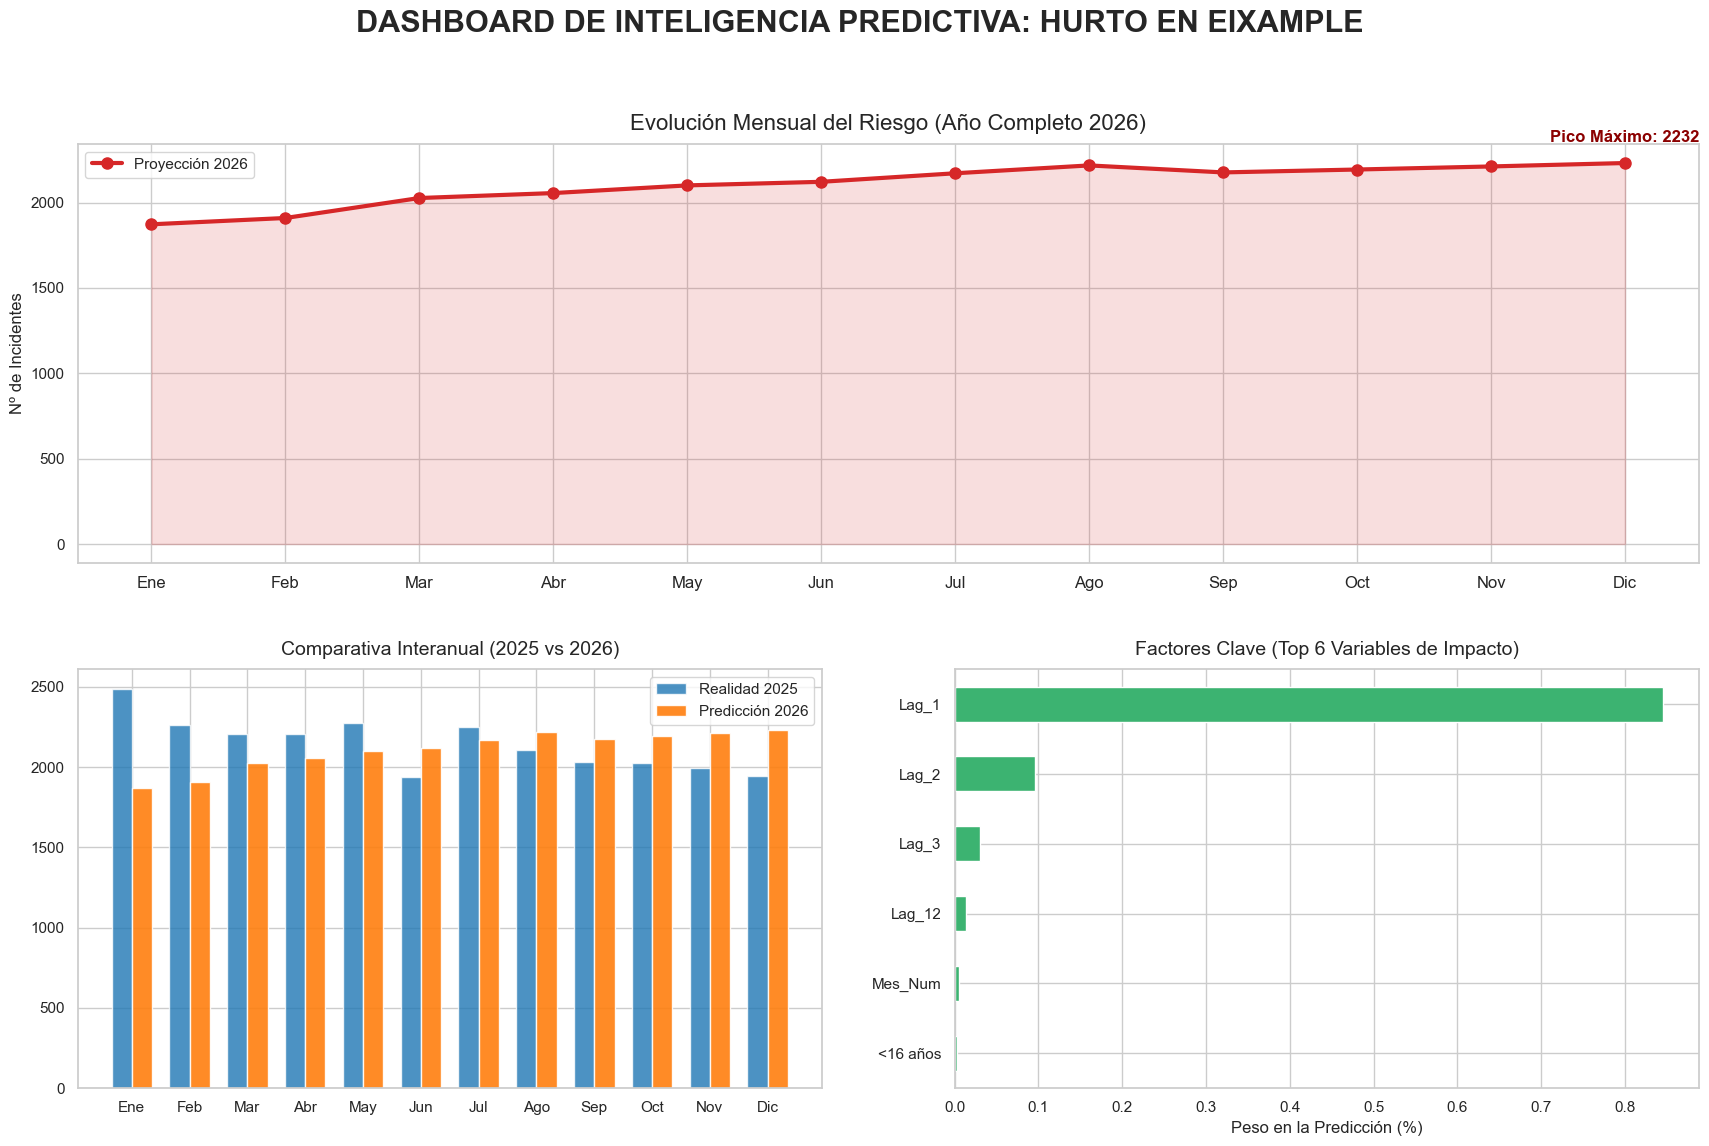


✅ CALENDARIO DE RIESGO 2026:


,0,1,2,3,4,5,6,7,8,9,10,11
Mes,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
Predicción_2026,1873,1910,2027,2056,2101,2122,2172,2218,2177,2194,2212,2232


📁 Datos exportados a: Plan_Seguridad_2026_Eixample_Hurto.xlsx


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display

print(f"🔮 Paso 3: Proyectando 2026 y generando Dashboard Visual para {DELITO} en {DISTRITO}...")

MAPA_MESES = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun', 
              7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}

# 1. Recuperar historial y contexto
historial = data['Cantidad'].tolist()
historial_2025 = data[data['Año'] == 2025]['Cantidad'].tolist() # Para la comparativa
ultimo_contexto = data.iloc[-1]

proyecciones = []

# 2. Bucle Recursivo
for mes_actual in range(1, 13):
    features_mes = np.array([[
        historial[-1], historial[-2], historial[-3], historial[-12], mes_actual,
        ultimo_contexto['16-64 años'], ultimo_contexto['<16 años'], ultimo_contexto['≥65 años'], 
        ultimo_contexto['España'], ultimo_contexto['Resto del mundo']
    ]])
    
    prediccion = modelo_rf.predict(features_mes)[0]
    proyecciones.append(int(prediccion))
    historial.append(prediccion)

df_2026 = pd.DataFrame({'Mes': list(MAPA_MESES.values()), 'Predicción_2026': proyecciones})

# =========================================================================
# 📊 DASHBOARD EJECUTIVO
# =========================================================================
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 12))
fig.suptitle(f'DASHBOARD DE INTELIGENCIA PREDICTIVA: {DELITO.upper()} EN {DISTRITO.upper()}', fontsize=22, fontweight='bold', y=0.98)

# --- GRÁFICO 1: Tendencia 2026 (Área) ---
ax1 = plt.subplot(2, 1, 1)
x_meses = np.arange(1, 13)
ax1.plot(x_meses, proyecciones, color='#d62728', marker='o', linewidth=3, markersize=8, label='Proyección 2026')
ax1.fill_between(x_meses, proyecciones, alpha=0.15, color='#d62728')

# Anotaciones de picos
pico_max = max(proyecciones)
mes_pico = proyecciones.index(pico_max) + 1
ax1.annotate(f'Pico Máximo: {pico_max}', xy=(mes_pico, pico_max), xytext=(0, 15), 
             textcoords='offset points', ha='center', fontweight='bold', color='darkred')

ax1.set_title("Evolución Mensual del Riesgo (Año Completo 2026)", fontsize=16, pad=10)
ax1.set_xticks(x_meses)
ax1.set_xticklabels(list(MAPA_MESES.values()), fontsize=12)
ax1.set_ylabel("Nº de Incidentes", fontsize=12)
ax1.legend(loc="upper left")

# --- GRÁFICO 2: Comparativa 2025 vs 2026 (Barras) ---
ax2 = plt.subplot(2, 2, 3)
ancho_barra = 0.35
# Validar que tenemos 12 meses de 2025, si no, lo ajustamos
if len(historial_2025) == 12:
    bar1 = ax2.bar(x_meses - ancho_barra/2, historial_2025, ancho_barra, label='Realidad 2025', color='#1f77b4', alpha=0.8)
    bar2 = ax2.bar(x_meses + ancho_barra/2, proyecciones, ancho_barra, label='Predicción 2026', color='#ff7f0e', alpha=0.9)
    ax2.set_title("Comparativa Interanual (2025 vs 2026)", fontsize=14, pad=10)
    ax2.set_xticks(x_meses)
    ax2.set_xticklabels(list(MAPA_MESES.values()))
    ax2.legend()
else:
    ax2.text(0.5, 0.5, "Datos de 2025 incompletos para comparativa", ha='center', va='center')

# --- GRÁFICO 3: Motor de Decisión (Importancia de Variables) ---
ax3 = plt.subplot(2, 2, 4)
importancias = pd.Series(modelo_rf.feature_importances_, index=features).sort_values(ascending=True)
importancias.tail(6).plot(kind='barh', color='mediumseagreen', ax=ax3) # Mostrar solo el Top 6
ax3.set_title("Factores Clave (Top 6 Variables de Impacto)", fontsize=14, pad=10)
ax3.set_xlabel("Peso en la Predicción (%)")

plt.tight_layout(pad=3.0)
plt.show()

# -------------------------------------------------------------------------
print("\n✅ CALENDARIO DE RIESGO 2026:")
display(df_2026.T) # Mostrar la tabla en horizontal para ahorrar espacio

# Guardar Excel
nombre_archivo = f"Plan_Seguridad_2026_{DISTRITO}_{DELITO}.xlsx"
df_2026.to_excel(nombre_archivo, index=False)
print(f"📁 Datos exportados a: {nombre_archivo}")

⚙️ Inicializando Motor de Inteligencia Criminal...
🔮 Generando Dashboard Visual 2026 para: Hurto en Eixample...


C:\Users\rcove\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\rcove\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\rcove\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\rcove\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\rcove\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\rcove\anaconda3\Lib\site-packages\sklearn\base.py:493: U

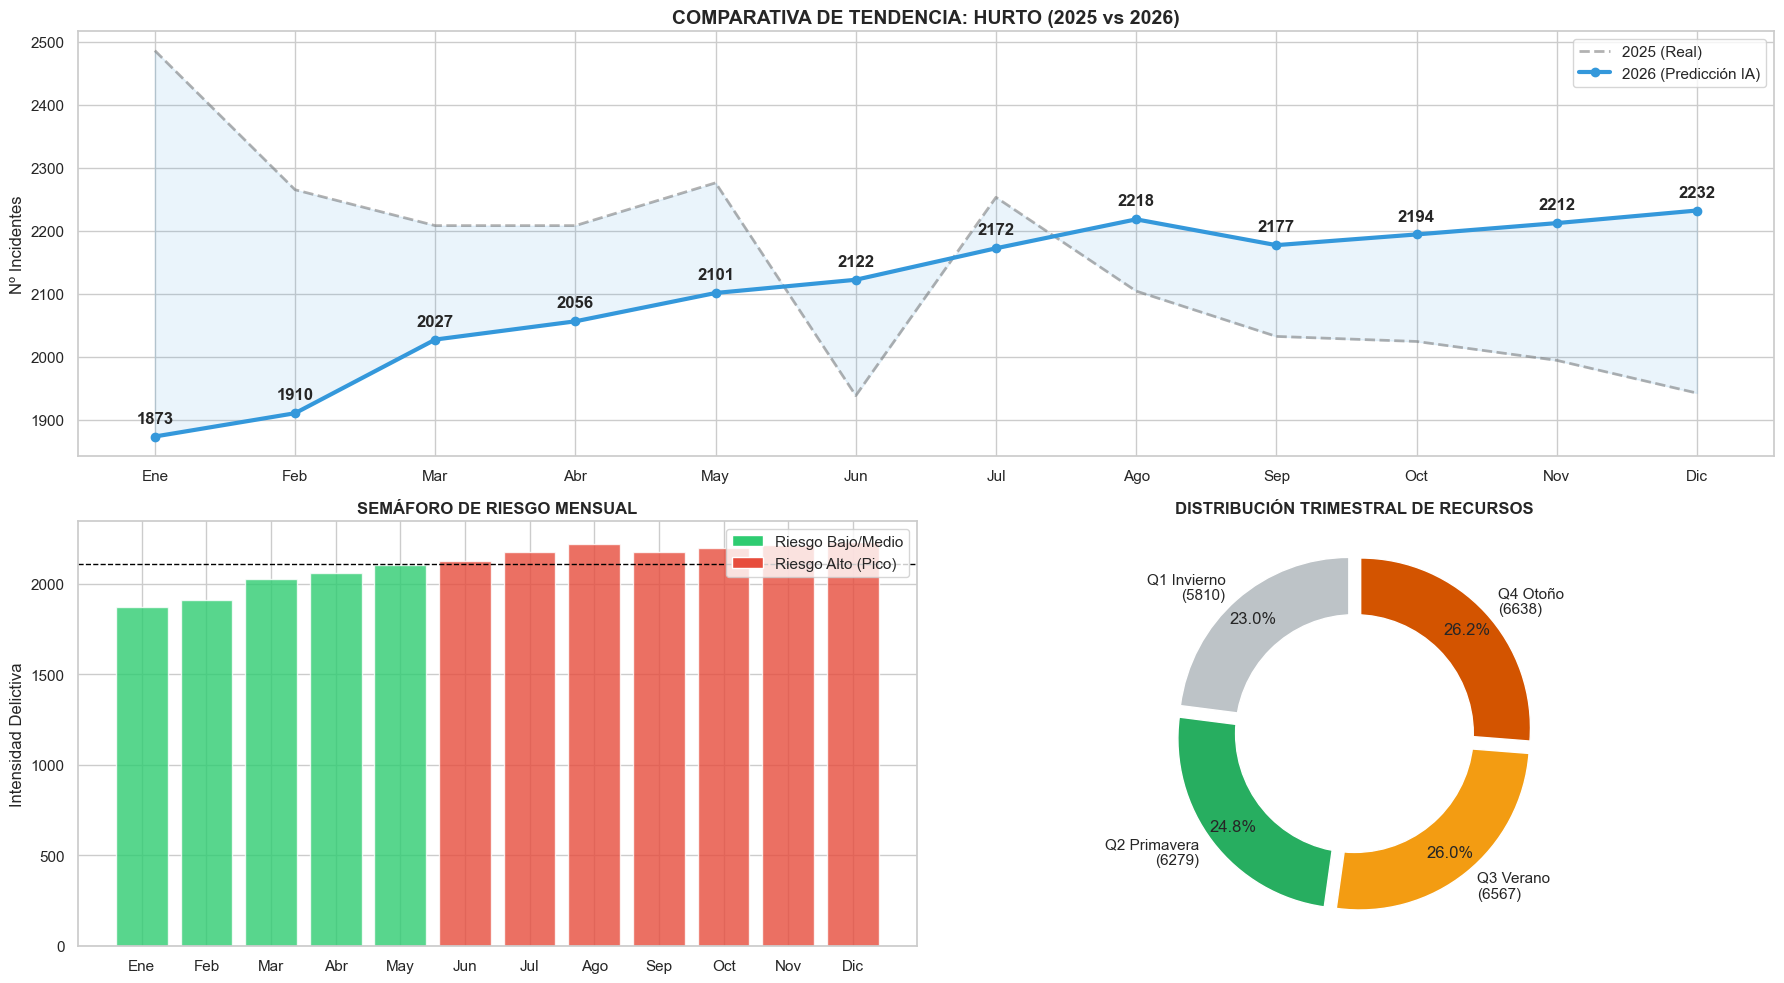

📊 RESUMEN EJECUTIVO 2026:
   - Total Incidentes Previstos: 25294
   - Mes Más Crítico: Dic con 2232 incidentes.
   - Trimestre con mayor actividad: Otoño


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from matplotlib.gridspec import GridSpec

# ==========================================
# 1. MOTOR DE INTELIGENCIA (Carga y Entrenamiento Rápido)
# ==========================================
print("⚙️ Inicializando Motor de Inteligencia Criminal...")

def limpiar_socio(path, pivot_col):
    df = pd.read_csv(path)
    if 'Poblacion' in path:
        df.columns = [str(col).split()[-1] if '01 ene' in str(col).lower() else col for col in df.columns]
        df = df[df['Tipo de territorio'].isin(['Municipi', 'Districte'])]
    cols_num = [c for c in df.columns if c not in ['Territorio', 'Tipo de territorio', pivot_col]]
    for col in cols_num:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False).str.replace('-', '0', regex=False).replace('', '0').astype(float)
    melted = df.melt(id_vars=['Territorio', 'Tipo de territorio', pivot_col], var_name='Año', value_name='Val')
    melted['Año'] = pd.to_numeric(melted['Año'], errors='coerce')
    return melted.pivot_table(index=['Territorio', 'Año'], columns=pivot_col, values='Val', aggfunc='first').reset_index()

# Carga de datos
df_edad = limpiar_socio('Edad_Barrios.csv', 'Edad en grandes grupos')
df_pob = limpiar_socio('Poblacion-Inmigrante.csv', 'Nacionalidad (España/UE/Resto extranjero)')
df_crime = pd.read_csv('Criminalidad_Mensual_Estructurada.csv')

# Fusión y limpieza
df_m = pd.merge(df_crime, df_edad, on=['Territorio', 'Año'], how='left')
df_m = pd.merge(df_m, df_pob, on=['Territorio', 'Año'], how='left')
social_cols = ['16-64 años', '<16 años', '≥65 años', 'España', 'Resto del mundo']
df_m = df_m.sort_values(['Territorio', 'Categoría_Delito', 'Año', 'Mes_Num'])
df_m[social_cols] = df_m.groupby(['Territorio', 'Categoría_Delito'])[social_cols].ffill()
df_m = df_m.dropna(subset=social_cols).reset_index(drop=True)

# Configuración del Objetivo
DISTRITO = 'Eixample' 
DELITO = 'Hurto'

# Preparación del Modelo
data = df_m[(df_m['Territorio'] == DISTRITO) & (df_m['Categoría_Delito'] == DELITO)].copy()
for i in [1, 2, 3, 12]: data[f'Lag_{i}'] = data['Cantidad'].shift(i)
data_train = data.dropna().reset_index(drop=True)

features = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_12', 'Mes_Num', '16-64 años', '<16 años', '≥65 años', 'España', 'Resto del mundo']
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(data_train[features], data_train['Cantidad'])

# ==========================================
# 2. PROYECCIÓN 2026
# ==========================================
print(f"🔮 Generando Dashboard Visual 2026 para: {DELITO} en {DISTRITO}...")

historial = data['Cantidad'].tolist()
ultimo_ctx = data.iloc[-1]
proyecciones = []

for mes in range(1, 13):
    feats = np.array([[historial[-1], historial[-2], historial[-3], historial[-12], mes,
                       ultimo_ctx['16-64 años'], ultimo_ctx['<16 años'], ultimo_ctx['≥65 años'], 
                       ultimo_ctx['España'], ultimo_ctx['Resto del mundo']]])
    pred = rf.predict(feats)[0]
    proyecciones.append(int(pred))
    historial.append(pred)

# Datos de 2025 para comparar
datos_2025 = data[data['Año'] == 2025]['Cantidad'].values
if len(datos_2025) < 12: # Relleno si faltan datos en 2025 para la gráfica
    datos_2025 = np.pad(datos_2025, (0, 12-len(datos_2025)), 'edge')

# ==========================================
# 3. VISUALIZACIÓN EJECUTIVA (DASHBOARD)
# ==========================================
sns.set_style("whitegrid")
fig = plt.figure(figsize=(18, 10))
gs = GridSpec(2, 2, figure=fig)

colores_meses = ['#2ecc71' if p < np.mean(proyecciones) else '#e74c3c' for p in proyecciones]
meses_abbr = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# GRÁFICA 1: Comparativa de Tendencia (Línea)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(meses_abbr, datos_2025, label='2025 (Real)', color='gray', linestyle='--', alpha=0.6, linewidth=2)
ax1.plot(meses_abbr, proyecciones, label='2026 (Predicción IA)', color='#3498db', marker='o', linewidth=3)
ax1.fill_between(meses_abbr, datos_2025, proyecciones, color='#3498db', alpha=0.1)
ax1.set_title(f"COMPARATIVA DE TENDENCIA: {DELITO.upper()} ({2025} vs {2026})", fontsize=14, fontweight='bold')
ax1.set_ylabel("Nº Incidentes")
ax1.legend()

# Etiquetas de valor en la predicción
for i, txt in enumerate(proyecciones):
    ax1.annotate(f"{txt}", (i, proyecciones[i]), xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')

# GRÁFICA 2: Semáforo de Riesgo Mensual (Barras)
ax2 = fig.add_subplot(gs[1, 0])
bars = ax2.bar(meses_abbr, proyecciones, color=colores_meses, alpha=0.8)
ax2.axhline(np.mean(proyecciones), color='black', linestyle='--', linewidth=1, label='Promedio Anual')
ax2.set_title("SEMÁFORO DE RIESGO MENSUAL", fontsize=12, fontweight='bold')
ax2.set_ylabel("Intensidad Delictiva")
# Leyenda personalizada para colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Riesgo Bajo/Medio'),
                   Patch(facecolor='#e74c3c', label='Riesgo Alto (Pico)')]
ax2.legend(handles=legend_elements, loc='upper right')

# GRÁFICA 3: Distribución Trimestral (Donut Chart)
ax3 = fig.add_subplot(gs[1, 1])
q1 = sum(proyecciones[0:3])
q2 = sum(proyecciones[3:6])
q3 = sum(proyecciones[6:9])
q4 = sum(proyecciones[9:12])
sizes = [q1, q2, q3, q4]
labels = [f'Q1 Invierno\n({q1})', f'Q2 Primavera\n({q2})', f'Q3 Verano\n({q3})', f'Q4 Otoño\n({q4})']
colors = ['#bdc3c7', '#27ae60', '#f39c12', '#d35400']
ax3.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, pctdistance=0.85, explode=(0.05, 0.05, 0.05, 0.05))
centre_circle = plt.Circle((0,0),0.70,fc='white')
ax3.add_artist(centre_circle)
ax3.set_title("DISTRIBUCIÓN TRIMESTRAL DE RECURSOS", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Resumen de Texto
print(f"📊 RESUMEN EJECUTIVO 2026:")
print(f"   - Total Incidentes Previstos: {sum(proyecciones)}")
print(f"   - Mes Más Crítico: {meses_abbr[np.argmax(proyecciones)]} con {max(proyecciones)} incidentes.")
print(f"   - Trimestre con mayor actividad: {['Invierno', 'Primavera', 'Verano', 'Otoño'][np.argmax([q1, q2, q3, q4])]}")